# ARC_ATLAS v4 Slice-Block Goal-0.8 Experiment

This notebook replaces the old axial 3-slice run with a higher-ceiling 2.5D setup aimed at the failure mode seen in the logs: small ATLAS lesions were under-detected or overcalled while large ARC lesions were already much better.

Design changes:

- 7-slice full-resolution blocks instead of 3-slice blocks.
- One whole brain per Keras step is preserved.
- Source + lesion-size balanced case sampling is enabled.
- Small-lesion brains get extra loss weight without making false positives free.
- Axial, sagittal, and coronal models are trained separately and then ensembled into one probability map.
- Whole-brain validation still writes per-epoch CSV/JSONL logs and NIfTI probability/segmentation outputs.


In [1]:
from pathlib import Path
import sys
import time
import json

candidates = [
    Path.cwd(),
    Path.cwd() / "ARC_ATLAS_Combined" / "ARC_ATLAS_Train_v4",
    Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4"),
]
PROJECT_ROOT = next(
    (p for p in candidates if (p / "src" / "training_v2_slice_blocks.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate ARC_ATLAS_Train_v4/src/training_v2_slice_blocks.py")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import training_v2_slice_blocks as seg

TRAIN_DIR = PROJECT_ROOT / "data" / "splits" / "90_10_random" / "train"
RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = PROJECT_ROOT / "runs" / f"{RUN_STAMP}_slice_blocks_triplanar_goal08"

AXIS_NAMES = {0: "sagittal", 1: "coronal", 2: "axial"}
AXES_TO_TRAIN = (2, 0, 1)  # axial first for direct comparison with the previous run, then sagittal/coronal for ensemble

COMMON_CFG = dict(
    DATA_DIR=TRAIN_DIR,
    IMAGES_DIR=TRAIN_DIR / "t1",
    MASKS_DIR=TRAIN_DIR / "masks",
    MANIFEST_PATH=TRAIN_DIR / "manifest.csv",
    TARGET_SHAPE=(192, 224, 192),
    RESAMPLE_TO_TARGET=False,
    BLOCK_DEPTH=7,
    SLICE_STRIDE=1,
    TOTAL_EPOCHS=90,
    INITIAL_LR=1.5e-4,
    MIN_LR=3e-6,
    WEIGHT_DECAY=1e-5,
    MAX_GRAD_NORM=1.0,
    MIXED_PRECISION=False,
    JIT_COMPILE=False,
    BASE_FILTERS=12,
    UNET_DEPTH=4,
    DROPOUT_RATE=0.08,
    L2_REG=1e-4,
    BALANCED_CASE_SAMPLING=True,
    SOURCE_BALANCED_SAMPLING=True,
    SIZE_AWARE_SAMPLING=True,
    SIZE_BUCKET_EDGES=(100, 1000, 10000),
    SIZE_BUCKET_PROBS=(0.32, 0.30, 0.23, 0.15),
    STEPS_PER_EPOCH=900,
    VALIDATION_STEPS=16,
    POSITIVE_WEIGHT=30.0,
    BCE_WEIGHT=0.36,
    DICE_WEIGHT=0.44,
    FOCAL_TVERSKY_WEIGHT=0.20,
    TVERSKY_ALPHA=0.55,
    TVERSKY_BETA=0.45,
    FOCAL_TVERSKY_GAMMA=1.33,
    LESION_SLICE_WEIGHT=1.35,
    EMPTY_SLICE_WEIGHT=0.90,
    DICE_ON_LESION_SLICES_ONLY=False,
    POSITIVE_TOPK_WEIGHT=0.045,
    POSITIVE_TOPK_FRACTION=0.35,
    SMALL_LESION_BOOST_REFERENCE=10000.0,
    SMALL_LESION_BOOST_MAX=2.5,
    AUGMENT=True,
    AUG_FLIP_PROB=0.5,
    AUG_INTENSITY_SCALE=0.08,
    AUG_INTENSITY_SHIFT=0.04,
    AUG_NOISE_STD=0.010,
    DECISION_THRESHOLD=0.25,
    VAL_THRESHOLD_SWEEP=(0.03, 0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80),
    WHOLE_BRAIN_VAL_EVERY_N_EPOCHS=1,
    WHOLE_BRAIN_VAL_MAX_CASES=None,
    SAVE_VAL_PREDICTIONS=True,
    NUM_VAL_PREDICTIONS=4,
    EARLY_STOPPING_PATIENCE=18,
    EARLY_STOPPING_MIN_DELTA=0.001,
    RESTORE_BEST_WEIGHTS=True,
    TARGET_WHOLE_DICE=0.80,
    FIT_VERBOSE=2,
)

def make_axis_cfg(axis: int):
    name = AXIS_NAMES[axis]
    axis_dir = RUN_DIR / f"axis{axis}_{name}"
    return seg.SliceBlockTrainingConfig(
        **COMMON_CFG,
        SLICE_AXIS=axis,
        MODEL_DIR=axis_dir / "models",
        CALLBACKS_DIR=axis_dir / "callbacks",
    )

axis_cfgs = {axis: make_axis_cfg(axis) for axis in AXES_TO_TRAIN}

print(f"Project root: {PROJECT_ROOT}")
print(f"Training data: {TRAIN_DIR}")
print(f"Run dir: {RUN_DIR}")
for axis, cfg in axis_cfgs.items():
    print(f"axis {axis} ({AXIS_NAMES[axis]}): input per brain = (num_slices, {cfg.input_shape[0]}, {cfg.input_shape[1]}, {cfg.input_shape[2]}), checkpoint = {cfg.checkpoint_path}")
print(f"Target whole-brain Dice stop: {COMMON_CFG['TARGET_WHOLE_DICE']}")


2026-04-22 17:14:47.709214: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Project root: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4
Training data: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train
Run dir: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08
axis 2 (axial): input per brain = (num_slices, 192, 224, 7), checkpoint = /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis2_axial/callbacks/best_slice_block.weights.h5
axis 0 (sagittal): input per brain = (num_slices, 224, 192, 7), checkpoint = /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis0_sagittal/callbacks/best_slice_block.weights.h5
axis 1 (coronal): input per brain = (num_slices, 192, 192, 7), checkpoint = /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_tripla

In [2]:
# Check split composition and the exact source/lesion-size problem this run is targeting.
import pandas as pd

base_cfg = axis_cfgs[2 if 2 in axis_cfgs else AXES_TO_TRAIN[0]]
cases = seg.load_cases(base_cfg)
train_cases, val_cases, lesion_sizes = seg.split_cases(cases, base_cfg)
size_by_id = {case.case_id: size for case, size in zip(cases, lesion_sizes)}

def split_frame(split_name, split_cases):
    return pd.DataFrame([
        {
            "split": split_name,
            "source": case.source,
            "case_id": case.case_id,
            "lesion_voxels": int(size_by_id[case.case_id]),
            "lesion_group": seg.lesion_size_group(int(size_by_id[case.case_id])),
        }
        for case in split_cases
    ])

split_df = pd.concat([split_frame("train", train_cases), split_frame("val", val_cases)], ignore_index=True)
display(split_df.groupby(["split", "source"]).size().unstack(fill_value=0))
display(split_df.groupby(["split", "lesion_group"]).size().unstack(fill_value=0))
display(split_df.groupby(["source", "lesion_group"]).size().unstack(fill_value=0))


2026-04-22 17:14:49,452 - SliceBlockTrainer - INFO - Using manifest: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train/manifest.csv
2026-04-22 17:14:49,473 - SliceBlockTrainer - INFO - Loaded 866 cases from manifest
2026-04-22 17:17:06,009 - SliceBlockTrainer - INFO - Split cases: train=737 val=129


source,ARC-combined-t1-raw-ab0d1794,ATLAS-Images-f0d7431e,Approx-Numeracy-Processed
split,,,
train,162,494,81
val,28,88,13


lesion_group,10000_plus,1000_9999,100_999,1_99,none
split,,,,,
train,366,199,150,19,3
val,64,35,26,4,0


lesion_group,10000_plus,1000_9999,100_999,1_99,none
source,,,,,
ARC-combined-t1-raw-ab0d1794,169,15,5,0,1
ATLAS-Images-f0d7431e,219,197,148,17,1
Approx-Numeracy-Processed,42,22,23,6,1


In [3]:
# Sanity check one whole-brain 7-slice batch and model size before launching training.
sanity_cfg = base_cfg
image, mask, _ = seg.load_case_arrays(cases[0], sanity_cfg)
x, y = seg.make_slice_blocks(image, mask, sanity_cfg)
model = seg.build_slice_block_model(sanity_cfg)

print(f"Cases: {len(cases)}")
print(f"Prepared brain: image={image.shape}, mask={mask.shape}")
print(f"One-brain batch: x={x.shape}, y={y.shape}")
print(f"Lesion voxels in sanity case: {int(y.sum())}")
print(f"Model params: {model.count_params():,}")

# Quick loss/shape smoke test without consuming a real epoch.
model.compile(optimizer="adam", loss=seg.WeightedBceDiceTversky(
    positive_weight=sanity_cfg.POSITIVE_WEIGHT,
    bce_weight=sanity_cfg.BCE_WEIGHT,
    dice_weight=sanity_cfg.DICE_WEIGHT,
    focal_tversky_weight=sanity_cfg.FOCAL_TVERSKY_WEIGHT,
    tversky_alpha=sanity_cfg.TVERSKY_ALPHA,
    tversky_beta=sanity_cfg.TVERSKY_BETA,
    focal_tversky_gamma=sanity_cfg.FOCAL_TVERSKY_GAMMA,
    lesion_slice_weight=sanity_cfg.LESION_SLICE_WEIGHT,
    empty_slice_weight=sanity_cfg.EMPTY_SLICE_WEIGHT,
    positive_topk_weight=sanity_cfg.POSITIVE_TOPK_WEIGHT,
    positive_topk_fraction=sanity_cfg.POSITIVE_TOPK_FRACTION,
    small_lesion_boost_reference=sanity_cfg.SMALL_LESION_BOOST_REFERENCE,
    small_lesion_boost_max=sanity_cfg.SMALL_LESION_BOOST_MAX,
))
loss_value = model.train_on_batch(x[:2], y[:2])
print(f"Smoke-test loss on 2 slices: {float(loss_value):.6f}")

del model
seg.tf.keras.backend.clear_session()


I0000 00:00:1776899826.937367  703666 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22148 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1776899826.938712  703666 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22122 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9


Cases: 866
Prepared brain: image=(192, 224, 192), mask=(192, 224, 192)
One-brain batch: x=(192, 192, 224, 7), y=(192, 192, 224, 1)
Lesion voxels in sanity case: 149459
Model params: 1,108,081


2026-04-22 17:17:11.293492: I external/local_xla/xla/service/service.cc:163] XLA service 0x30954d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-22 17:17:11.293509: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-22 17:17:11.293512: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-22 17:17:11.430225: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-22 17:17:12.104154: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91001


Smoke-test loss on 2 slices: 0.996555


I0000 00:00:1776899840.157232  703666 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


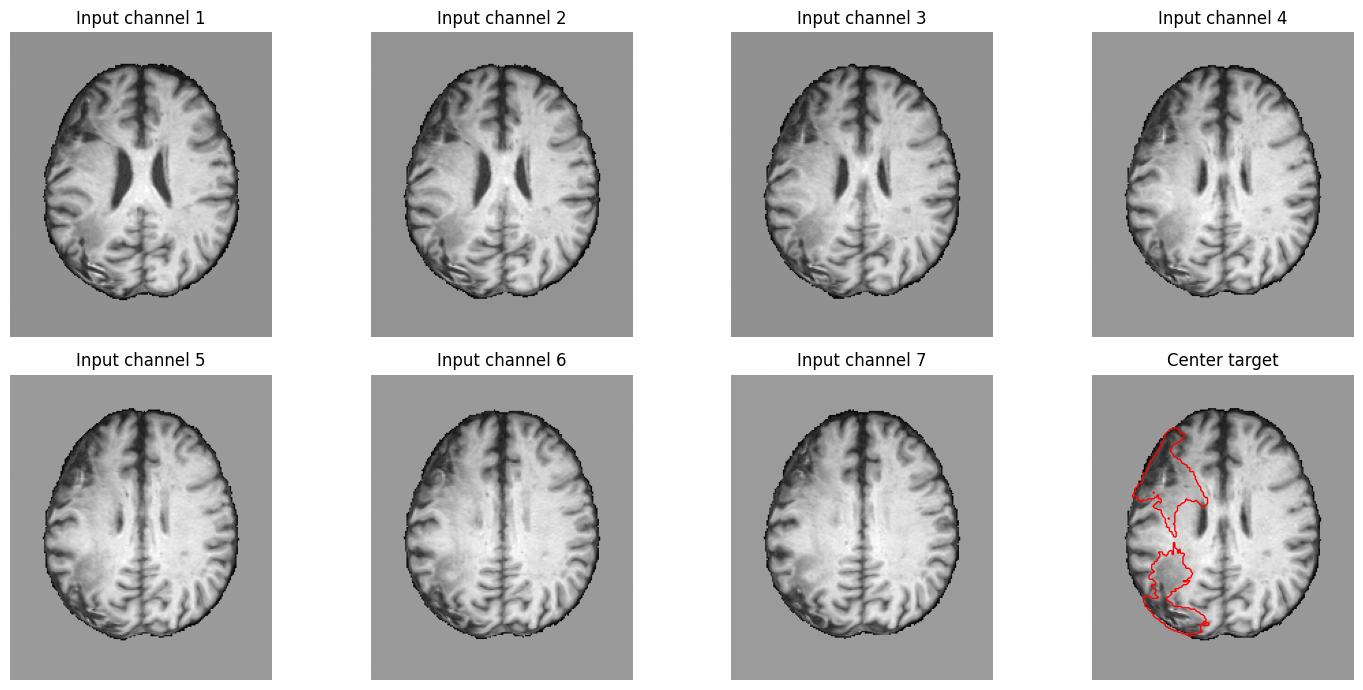

In [4]:
# Visual sanity check for one 7-slice input block and center-slice target.
import matplotlib.pyplot as plt
import numpy as np

center_idx = int(np.argmax(y.reshape(y.shape[0], -1).sum(axis=1)))
block = x[center_idx]
target = y[center_idx, ..., 0]
center_channel = sanity_cfg.BLOCK_DEPTH // 2

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for channel, ax in enumerate(axes.flat[:sanity_cfg.BLOCK_DEPTH]):
    ax.imshow(block[..., channel].T, cmap="gray", origin="lower")
    ax.set_title(f"Input channel {channel + 1}")
    ax.axis("off")
axes.flat[-1].imshow(block[..., center_channel].T, cmap="gray", origin="lower")
if target.any():
    axes.flat[-1].contour(target.T, levels=[0.5], colors=["red"], linewidths=1.0)
axes.flat[-1].set_title("Center target")
axes.flat[-1].axis("off")
plt.tight_layout()


In [5]:
# Launch staged training. Each axis writes its own epoch logs, checkpoints, and whole-brain predictions.
# This can run for a long time. If interrupted after one axis, rerun from this cell after editing AXES_TO_TRAIN above to the remaining axes.
histories = {}
for axis, cfg in axis_cfgs.items():
    print("=" * 100)
    print(f"Training axis {axis} ({AXIS_NAMES[axis]})")
    print(f"Run callbacks: {cfg.CALLBACKS_DIR}")
    histories[axis] = seg.train_slice_block_model(cfg)
    seg.tf.keras.backend.clear_session()
    print(f"Finished axis {axis}. Best checkpoint: {cfg.checkpoint_path}")


2026-04-22 17:17:20,768 - SliceBlockTrainer - WARNING - Could not set memory growth on PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'): Physical devices cannot be modified after being initialized
2026-04-22 17:17:20,769 - SliceBlockTrainer - WARNING - Could not set memory growth on PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'): Physical devices cannot be modified after being initialized
2026-04-22 17:17:20,769 - SliceBlockTrainer - INFO - Using manifest: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train/manifest.csv
2026-04-22 17:17:20,789 - SliceBlockTrainer - INFO - Loaded 866 cases from manifest


Training axis 2 (axial)
Run callbacks: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis2_axial/callbacks


2026-04-22 17:19:29,112 - SliceBlockTrainer - INFO - Split cases: train=737 val=129
2026-04-22 17:19:29,126 - SliceBlockTrainer - INFO - Balanced case sampling enabled: source_balanced=True size_aware=True size_edges=(100, 1000, 10000) size_probs=(0.32, 0.3, 0.23, 0.15)
2026-04-22 17:19:29,329 - SliceBlockTrainer - INFO - Model built: SliceBlock2p5D_UNet params=1108081 input=(192, 224, 7)
2026-04-22 17:19:29,329 - SliceBlockTrainer - INFO - Slice-block design: one brain per step, block_depth=7 slice_axis=2 stride=1 train_steps=900 val_steps=16
2026-04-22 17:19:29,329 - SliceBlockTrainer - INFO - Loss focus: lesion_slice_weight=1.350 empty_slice_weight=0.900 small_lesion_boost=(ref=10000.0 max=2.50) dice_lesion_only=False positive_topk_weight=0.045 topk_fraction=0.350 tversky=(alpha=0.550 beta=0.450) threshold=0.250


Epoch 1/90


E0000 00:00:1776899974.929383  703666 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/SliceBlock2p5D_UNet_1/enc1_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-04-22 17:47:18,555 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 16/129
2026-04-22 17:47:49,919 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 32/129
2026-04-22 17:48:21,160 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 48/129
2026-04-22 17:48:52,486 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 64/129
2026-04-22 17:49:23,692 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 80/129
2026-04-22 17:49:55,078 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 96/129
2026-04-22 17:50:26,409 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 112/129
2026-04-22 17:50:57,630

...


Epoch 88: val_whole_dice_hard_best_thr_score did not improve from 0.37137
900/900 - 1832s - 2s/step - dice_coefficient: 0.0749 - foreground_fraction: 0.0084 - hard_dice_metric: 0.6479 - loss: 0.6044 - val_dice_coefficient: 0.0877 - val_foreground_fraction: 0.0057 - val_hard_dice_metric: 0.6936 - val_loss: 0.7514 - val_whole_dice_soft_macro: 0.3036 - val_whole_dice_hard: 0.3164 - val_whole_dice_hard_best_thr: 0.8000 - val_whole_dice_hard_best_thr_score: 0.3625
Epoch 89/90


2026-04-27 08:46:58,920 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 16/129
2026-04-27 08:47:24,894 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 32/129
2026-04-27 08:47:50,715 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 48/129
2026-04-27 08:48:16,574 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 64/129
2026-04-27 08:48:42,448 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 80/129
2026-04-27 08:49:08,177 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 96/129
2026-04-27 08:49:34,047 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 112/129
2026-04-27 08:49:59,967 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 128/129
2026-04-27 08:50:01,548 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 129/129
2026-04-27 08:50:01,553 - SliceBlockTrainer - INFO - Whole-brain slice-block val @epoch 88: soft=0.30230 hard@0.25=


Epoch 89: val_whole_dice_hard_best_thr_score did not improve from 0.37137
900/900 - 1837s - 2s/step - dice_coefficient: 0.0745 - foreground_fraction: 0.0094 - hard_dice_metric: 0.6409 - loss: 0.6074 - val_dice_coefficient: 0.0870 - val_foreground_fraction: 0.0055 - val_hard_dice_metric: 0.6940 - val_loss: 0.7545 - val_whole_dice_soft_macro: 0.3023 - val_whole_dice_hard: 0.3150 - val_whole_dice_hard_best_thr: 0.8000 - val_whole_dice_hard_best_thr_score: 0.3621
Epoch 90/90


2026-04-27 09:17:35,946 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 16/129
2026-04-27 09:18:01,643 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 32/129
2026-04-27 09:18:27,581 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 48/129
2026-04-27 09:18:53,345 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 64/129
2026-04-27 09:19:19,085 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 80/129
2026-04-27 09:19:44,867 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 96/129
2026-04-27 09:20:10,576 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 112/129
2026-04-27 09:20:36,339 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 128/129
2026-04-27 09:20:37,927 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 129/129
2026-04-27 09:20:37,932 - SliceBlockTrainer - INFO - Whole-brain slice-block val @epoch 89: soft=0.30125 hard@0.25=


Epoch 90: val_whole_dice_hard_best_thr_score did not improve from 0.37137
900/900 - 1836s - 2s/step - dice_coefficient: 0.0773 - foreground_fraction: 0.0093 - hard_dice_metric: 0.6360 - loss: 0.6068 - val_dice_coefficient: 0.0888 - val_foreground_fraction: 0.0058 - val_hard_dice_metric: 0.6950 - val_loss: 0.7412 - val_whole_dice_soft_macro: 0.3013 - val_whole_dice_hard: 0.3144 - val_whole_dice_hard_best_thr: 0.8000 - val_whole_dice_hard_best_thr_score: 0.3626
Restoring model weights from the end of the best epoch: 75.
Finished axis 1. Best checkpoint: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis1_coronal/callbacks/best_slice_block.weights.h5


In [6]:
# Review per-axis epoch logs and source/lesion-group breakdowns.
import json
import pandas as pd

for axis, cfg in axis_cfgs.items():
    print("=" * 100)
    print(f"axis {axis} ({AXIS_NAMES[axis]})")
    summary_path = cfg.CALLBACKS_DIR / "whole_val_summary.jsonl"
    train_log = cfg.CALLBACKS_DIR / "training_log.csv"
    if train_log.exists():
        display(pd.read_csv(train_log).tail(8))
    else:
        print(f"No training log yet: {train_log}")
    if not summary_path.exists():
        print(f"No whole-brain summary yet: {summary_path}")
        continue
    rows = [json.loads(line) for line in summary_path.read_text().splitlines() if line.strip()]
    summary_df = pd.DataFrame(rows)
    display(summary_df.tail(8))
    best_epoch = int(summary_df.loc[summary_df["val_whole_dice_hard_best_thr_score"].idxmax(), "epoch"])
    best_csv = cfg.CALLBACKS_DIR / f"whole_val_epoch_{best_epoch:04d}.csv"
    print(f"best epoch: {best_epoch}, csv: {best_csv}")
    if best_csv.exists():
        case_df = pd.read_csv(best_csv)
        display(case_df.groupby("source")["best_threshold_dice"].agg(["count", "mean", "median"]))
        display(case_df.groupby("lesion_group")["best_threshold_dice"].agg(["count", "mean", "median"]))


axis 2 (axial)


,epoch,dice_coefficient,foreground_fraction,hard_dice_metric,loss,val_dice_coefficient,val_foreground_fraction,val_hard_dice_metric,val_loss,val_whole_dice_hard,val_whole_dice_hard_best_thr,val_whole_dice_hard_best_thr_score,val_whole_dice_soft_macro
39,39,0.061403,0.009892,0.551615,0.641171,0.094396,0.008724,0.544578,0.687805,0.237808,0.8,0.297397,0.227058
40,40,0.070034,0.010580,0.544864,0.635988,0.090239,0.005092,0.712209,0.732624,0.299899,0.5,0.343252,0.247381
41,41,0.063939,0.010813,0.546306,0.650398,0.097618,0.008126,0.672335,0.685214,0.278395,0.8,0.335503,0.253274
42,42,0.063998,0.009993,0.555377,0.641398,0.094326,0.008480,0.566905,0.685676,0.254810,0.8,0.322157,0.237023
43,43,0.063798,0.010004,0.545088,0.640801,0.098873,0.006653,0.709361,0.704939,0.294183,0.8,0.345126,0.266609
44,44,0.064562,0.009013,0.564248,0.636408,0.098157,0.006571,0.696679,0.705855,0.295518,0.8,0.347440,0.270142
45,45,0.066244,0.008532,0.579083,0.629567,0.096939,0.008582,0.709269,0.689377,0.276389,0.8,0.340603,0.253097
46,46,0.067122,0.007912,0.583115,0.627036,0.097639,0.006330,0.633230,0.713512,0.284105,0.8,0.329473,0.259711


,epoch,elapsed_sec,n_cases,val_whole_dice_soft_macro,val_whole_dice_hard,val_whole_dice_hard_best_thr,val_whole_dice_hard_best_thr_score,pred_max_p90,pred_hard_voxels_median
39,39,252.243428,129,0.227058,0.237808,0.8,0.297397,0.996816,57541.0
40,40,254.071446,129,0.247381,0.299899,0.5,0.343252,0.993815,25418.0
41,41,252.146608,129,0.253274,0.278395,0.8,0.335503,0.996194,37141.0
42,42,251.066570,129,0.237023,0.254810,0.8,0.322157,0.995313,56806.0
43,43,253.976683,129,0.266609,0.294183,0.8,0.345126,0.995027,32735.0
44,44,252.802733,129,0.270142,0.295518,0.8,0.347440,0.995675,31052.0
45,45,252.320015,129,0.253097,0.276389,0.8,0.340603,0.997134,36085.0
46,46,255.683876,129,0.259711,0.284105,0.8,0.329473,0.995070,33814.0


best epoch: 28, csv: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis2_axial/callbacks/whole_val_epoch_0028.csv


,count,mean,median
source,,,
ARC-combined-t1-raw-ab0d1794,28,0.634467,0.726792
ATLAS-Images-f0d7431e,88,0.256620,0.220589
Approx-Numeracy-Processed,13,0.379226,0.442857


...

,epoch,dice_coefficient,foreground_fraction,hard_dice_metric,loss,val_dice_coefficient,val_foreground_fraction,val_hard_dice_metric,val_loss,val_whole_dice_hard,val_whole_dice_hard_best_thr,val_whole_dice_hard_best_thr_score,val_whole_dice_soft_macro
82,82,0.081823,0.009760,0.636758,0.603329,0.089520,0.006094,0.699487,0.734066,0.310180,0.8,0.358540,0.299129
83,83,0.077124,0.009366,0.633533,0.605047,0.087232,0.005981,0.684184,0.741294,0.303691,0.8,0.355214,0.292994
84,84,0.078592,0.009271,0.647426,0.606351,0.089503,0.006084,0.700107,0.729775,0.309249,0.8,0.361474,0.297442
85,85,0.078124,0.009622,0.649465,0.605110,0.087373,0.005669,0.698909,0.739013,0.310651,0.8,0.362324,0.293750
86,86,0.070831,0.007779,0.665933,0.607760,0.088520,0.005802,0.693050,0.745137,0.314470,0.8,0.360150,0.302354
87,87,0.074885,0.008408,0.647914,0.604396,0.087656,0.005681,0.693573,0.751379,0.316414,0.8,0.362477,0.303552
88,88,0.074540,0.009373,0.640879,0.607422,0.086963,0.005533,0.693964,0.754538,0.314995,0.8,0.362069,0.302299
89,89,0.077294,0.009347,0.635987,0.606758,0.088812,0.005793,0.694990,0.741212,0.314406,0.8,0.362603,0.301253


,epoch,elapsed_sec,n_cases,val_whole_dice_soft_macro,val_whole_dice_hard,val_whole_dice_hard_best_thr,val_whole_dice_hard_best_thr_score,pred_max_p90,pred_hard_voxels_median
82,82,207.259210,129,0.299129,0.310180,0.8,0.358540,0.996201,31694.0
83,83,212.528893,129,0.292994,0.303691,0.8,0.355214,0.995777,32513.0
84,84,207.964474,129,0.297442,0.309249,0.8,0.361474,0.995214,30343.0
85,85,208.505398,129,0.293750,0.310651,0.8,0.362324,0.995166,30385.0
86,86,213.177353,129,0.302354,0.314470,0.8,0.360150,0.996455,29203.0
87,87,208.961163,129,0.303552,0.316414,0.8,0.362477,0.996034,28167.0
88,88,208.666965,129,0.302299,0.314995,0.8,0.362069,0.996495,28933.0
89,89,207.869635,129,0.301253,0.314406,0.8,0.362603,0.996114,29154.0


best epoch: 74, csv: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis1_coronal/callbacks/whole_val_epoch_0074.csv


,count,mean,median
source,,,
ARC-combined-t1-raw-ab0d1794,28,0.659027,0.742039
ATLAS-Images-f0d7431e,88,0.281796,0.228433
Approx-Numeracy-Processed,13,0.358169,0.203156


,count,mean,median
lesion_group,,,
10000_plus,64,0.535180,0.675227
1000_9999,35,0.251030,0.177344
100_999,26,0.170583,0.076034
1_99,4,0.108569,0.085366


In [7]:
# Evaluate the tri-planar probability-map ensemble after at least one axis has produced best weights.
trained_axes = [axis for axis, cfg in axis_cfgs.items() if cfg.checkpoint_path.exists()]
if not trained_axes:
    raise FileNotFoundError("No axis checkpoint exists yet. Run the training cell first.")

trained_cfgs = [axis_cfgs[axis] for axis in trained_axes]
weights_paths = [axis_cfgs[axis].checkpoint_path for axis in trained_axes]
ensemble_dir = RUN_DIR / "ensemble"

summary = seg.evaluate_slice_block_ensemble(
    configs=trained_cfgs,
    weights_paths=weights_paths,
    out_dir=ensemble_dir,
    thresholds=COMMON_CFG["VAL_THRESHOLD_SWEEP"],
    decision_threshold=COMMON_CFG["DECISION_THRESHOLD"],
    save_predictions=6,
)

print(json.dumps(summary, indent=2))
print(f"Ensemble CSV: {ensemble_dir / 'ensemble_val.csv'}")
print(f"Ensemble predictions: {ensemble_dir / 'predictions'}")


2026-04-27 09:20:38,768 - SliceBlockTrainer - INFO - Using manifest: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train/manifest.csv
2026-04-27 09:20:38,787 - SliceBlockTrainer - INFO - Loaded 866 cases from manifest
2026-04-27 09:22:09,231 - SliceBlockTrainer - INFO - Split cases: train=737 val=129
2026-04-27 09:23:39,620 - SliceBlockTrainer - INFO - Slice-block ensemble val progress: 16/129
2026-04-27 09:24:47,683 - SliceBlockTrainer - INFO - Slice-block ensemble val progress: 32/129
2026-04-27 09:25:56,329 - SliceBlockTrainer - INFO - Slice-block ensemble val progress: 48/129
2026-04-27 09:27:05,059 - SliceBlockTrainer - INFO - Slice-block ensemble val progress: 64/129
2026-04-27 09:28:13,783 - SliceBlockTrainer - INFO - Slice-block ensemble val progress: 80/129
2026-04-27 09:29:22,690 - SliceBlockTrainer - INFO - Slice-block ensemble val progress: 96/129
2026-04-27 09:30:31,451 - SliceBlockTrainer - INFO - Slice-block ensemble val pro

{
  "elapsed_sec": 574.6492536067963,
  "n_cases": 129,
  "weights_paths": [
    "/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis2_axial/callbacks/best_slice_block.weights.h5",
    "/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis0_sagittal/callbacks/best_slice_block.weights.h5",
    "/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/axis1_coronal/callbacks/best_slice_block.weights.h5"
  ],
  "axes": [
    2,
    0,
    1
  ],
  "block_depths": [
    7,
    7,
    7
  ],
  "decision_threshold": 0.25,
  "val_whole_dice_soft_macro": 0.2586254336207459,
  "val_whole_dice_hard": 0.3212723126391323,
  "val_whole_dice_hard_best_thr": 0.45,
  "val_whole_dice_hard_best_thr_score": 0.41278368140259375,
  "source_best_threshold_dice": {
    "ARC-combined-t1-raw-ab0d1794": 0.67522

In [ ]:
# Export one manual ensemble probability map and threshold segmentation for visual inspection.
trained_axes = [axis for axis, cfg in axis_cfgs.items() if cfg.checkpoint_path.exists()]
if not trained_axes:
    raise FileNotFoundError("No axis checkpoint exists yet. Run the training cell first.")

models = [seg.load_slice_block_model(axis_cfgs[axis], axis_cfgs[axis].checkpoint_path) for axis in trained_axes]
trained_cfgs = [axis_cfgs[axis] for axis in trained_axes]
case = val_cases[0]
prob, mask, ref_img = seg.predict_ensemble_probability_map(models, trained_cfgs, case)
out_dir = RUN_DIR / "manual_ensemble_prediction"
seg.save_case_outputs(out_dir, case, prob, COMMON_CFG["DECISION_THRESHOLD"], ref_img)

print(f"Saved probability map and threshold segmentation to: {out_dir}")
print(f"Case: {case.case_id}")
print(f"Probability range: min={float(prob.min()):.6f}, max={float(prob.max()):.6f}")
print(f"Threshold voxels @ {COMMON_CFG['DECISION_THRESHOLD']:.2f}: {int((prob >= COMMON_CFG['DECISION_THRESHOLD']).sum())}")
seg.tf.keras.backend.clear_session()


Saved probability map and threshold segmentation to: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260422_171449_slice_blocks_triplanar_goal08/manual_ensemble_prediction
Case: ATLAS-Images-f0d7431e__ATLAS-Images-f0d7431e__sub-r011s017_ses-1_space-MNI152NLin2009aSym_T1w_MNI_norm
Probability range: min=0.000026, max=0.992670
Threshold voxels @ 0.25: 6311


: 